In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [110]:
df = pd.read_csv(r"C:\Users\soura\OneDrive\Desktop\Crypto Currency\data\processed\featured_data.csv")

print(df.shape)
df.head()

(3218, 41)


,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,returns,...,ret_vol_interaction,zscore_vol,range_pct,trend_strength,high_vol_regime,return_acc,momentum_3,ma_diff,vol_breakout,return_strength
0,122.500000,122.500000,116.000000,122.222000,0.0,1.373708e+09,2013-06-03T23:59:59.999Z,Bitcoin,2013-06-03,-0.000572,...,-0.000013,-0.086956,0.053182,2.898300,0,0.053627,-0.052543,2.898300,0,-0.015470
1,120.737000,123.839996,119.099998,121.419998,0.0,1.365338e+09,2013-06-04T23:59:59.999Z,Bitcoin,2013-06-04,-0.006562,...,-0.000149,-0.075012,0.039038,1.482300,0,-0.005989,-0.060944,1.482300,0,-0.011490
2,121.400002,123.469002,119.899002,121.650002,0.0,1.368486e+09,2013-06-05T23:59:59.999Z,Bitcoin,2013-06-05,0.001894,...,0.000042,-0.043983,0.029346,0.154801,0,0.008456,-0.005250,0.154801,0,-0.011423
3,121.900002,123.099998,117.250000,118.000000,0.0,1.327960e+09,2013-06-06T23:59:59.999Z,Bitcoin,2013-06-06,-0.030004,...,-0.000666,-0.014953,0.049576,-0.768949,0,-0.031898,-0.034544,-0.768949,0,-0.017889
4,118.970001,119.000000,106.419998,111.500000,0.0,1.255259e+09,2013-06-07T23:59:59.999Z,Bitcoin,2013-06-07,-0.055085,...,-0.001455,0.039476,0.112825,-1.919049,1,-0.025081,-0.081700,-1.919049,1,-0.018066


In [111]:
# Drop target and all non-numeric columns (timestamp, crypto_name, date, etc.)
X = df.drop('target', axis=1)
X = X.select_dtypes(include='number')  # key fix: removes all string columns
y = df['target']

print("Features:", X.columns.tolist())


Features: ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'returns', 'volatility', 'vol_lag1', 'vol_lag2', 'vol_lag3', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'vol_5', 'vol_10', 'vol_20', 'hl_diff', 'co_diff', 'ma_5', 'ma_10', 'ma_20', 'ma_ratio', 'momentum_5', 'vol_of_vol', 'trend_10', 'vol_change', 'ret_vol_interaction', 'zscore_vol', 'range_pct', 'trend_strength', 'high_vol_regime', 'return_acc', 'momentum_3', 'ma_diff', 'vol_breakout', 'return_strength']


In [112]:
tscv = TimeSeriesSplit(n_splits=5)

splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2682, 37)
Test size: (536, 37)


In [113]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"R2   : {r2:.6f}")

In [114]:
naive_pred = X_test['vol_lag1']
evaluate(y_test, naive_pred, "Naive Model")


Naive Model
MAE  : 0.525850
RMSE : 0.696883
R2   : -0.947901


In [115]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

evaluate(y_test, rf_preds, "Random Forest")


Random Forest
MAE  : 0.490744
RMSE : 0.496198
R2   : 0.012454


In [116]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

evaluate(y_test, xgb_preds, "XGBoost")


XGBoost
MAE  : 0.475595
RMSE : 0.500065
R2   : -0.002998


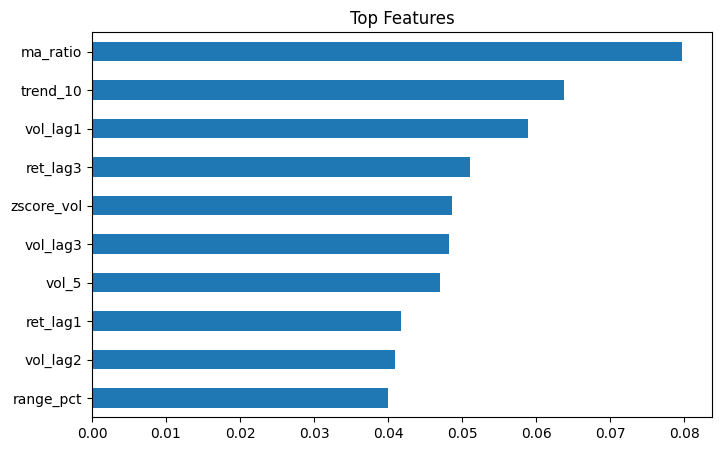

In [117]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh')
plt.title("Top Features")
plt.gca().invert_yaxis()
plt.show()

In [118]:
scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    scores.append(r2_score(y_test, preds))

print("\nWalk-forward R2:", np.mean(scores))


Walk-forward R2: 0.016037774194545284


In [119]:
X_no_lag = X.drop(columns=['vol_lag1'])

splits = list(tscv.split(X_no_lag))
train_idx, test_idx = splits[-1]

X_train, X_test = X_no_lag.iloc[train_idx], X_no_lag.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf.fit(X_train, y_train)
preds = rf.predict(X_test)

evaluate(y_test, preds, "RF without vol_lag1")


RF without vol_lag1
MAE  : 0.489708
RMSE : 0.495226
R2   : 0.016322


In [120]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_clf = XGBClassifier(n_estimators=300, max_depth=6)

xgb_clf.fit(X_train, y_train)
preds = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.582089552238806


In [121]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[124 130]
 [ 94 188]]
              precision    recall  f1-score   support

           0       0.57      0.49      0.53       254
           1       0.59      0.67      0.63       282

    accuracy                           0.58       536
   macro avg       0.58      0.58      0.58       536
weighted avg       0.58      0.58      0.58       536

